# nb07b — Long-Term vs. Short-Term Parkeergedrag: EDA & Hypothesetoetsing
**Auteur:** Emile Van de Voorde  
**Datum:** 2026-03  
**Status:** Aanvullende EDA — uitvoeren vóór nb08  
**Afhankelijkheden:** MAD_shortterm.parquet · MAD_longterm.parquet · eda_config.py

---

## Doel van dit notebook

Dit notebook beantwoordt één fundamentele vraag die in nb05–nb07 open
is gebleven: **meten de sensoren short-term (ST) en long-term (LT)
bezetting gescheiden, of zitten beide groepen samengevat in één
`occupancy_rate`?**

Het antwoord bepaalt of de target-variabele in alle verdere
modellering (nb09–nb13) methodologisch correct is.

Drie formele hypothesen worden getoetst:

| Code | Stelling |
|---|---|
| H-LT1 | LT-abonnees vertonen significant lagere dagelijkse variabiliteit dan ST-gebruikers |
| H-LT2 | LT-bezetting correleert significant zwakker met externe factoren (neerslag, events) dan ST |
| H-LT3 | De Bland-Altman analyse toont systematische bias en brede LoA tussen ST en LT |

> **Causaliteitsvoorbehoud:** Alle analyses in dit notebook zijn
> associatief. Causaliteit kan niet worden vastgesteld op basis van
> observationele tijdreeksdata (James et al., 2021, p. 59).


In [5]:
# ── CEL 01 · Config & laden ──────────────────────────────────────────
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── Paden (conform nb05/nb06/nb07) ───────────────────────────────────
ROOT      = Path("/Users/emilevandevoorde/Documents/mechelen_parking")
DATA_PROC = ROOT / "data_processed"
DATA_INT  = ROOT / "data_intermediate"
FIGS      = ROOT / "figures" / "eda" / "nb07b"
FIGS.mkdir(parents=True, exist_ok=True)

# ── Data laden ───────────────────────────────────────────────────────
mad_st = pd.read_parquet(DATA_PROC / "MAD_shortterm.parquet")
mad_lt = pd.read_parquet(DATA_PROC / "MAD_longterm.parquet")
df_loc = pd.read_parquet(DATA_INT  / "parking_location_clean.parquet")

# ── Trainingsfilter (NOOIT WIJZIGEN) ─────────────────────────────────
def get_train_mask(df):
    return (
        (df["low_data_coverage"] == 0) &
        (df["system_blackout"]   == 0) &
        (df["partial_year"]      == 0) &
        (df["year"]              >= 2020) &
        (df["year"]              != 2025)
    )

st_train = mad_st[get_train_mask(mad_st)].copy()
lt_train = mad_lt[get_train_mask(mad_lt)].copy()

# ── Tier-samenvoeging (conform nb05/nb06/nb07) ────────────────────────
for df in [st_train, lt_train]:
    df["tier"] = (df["parking_location_category"]
                  .astype(str)
                  .replace({"rand": "vesten_of_rand", 
                             "vesten": "vesten_of_rand"}))

print(f"ST trainingsset : {len(st_train):>7,} rijen")
print(f"LT trainingsset : {len(lt_train):>7,} rijen")
print(f"ST parkings     : {st_train['parking_id'].nunique()}")
print(f"LT parkings     : {lt_train['parking_id'].nunique()}")
print(f"LT aanwezig     : {sorted(lt_train['parking_id'].unique())}")


ST trainingsset : 129,837 rijen
LT trainingsset :  46,643 rijen
ST parkings     : 10
LT parkings     : 7
LT aanwezig     : ['P Grote Markt', 'P Hoogstraat', 'P Kathedraal', 'P Keerdok', 'P Komet', 'P Maarten', 'P Tinel']


## CEL 02 · Data-provenancevraag: Scenario A of B?

### Conceptueel kader

Vooraleer hypothesen te toetsen, moet de meetstructuur worden
vastgesteld. Twee scenario's zijn mogelijk:

- **Scenario A** — ST en LT worden apart gemeten (aparte sensortellers).
  `MAD_shortterm.occupancy_rate` bevat dan enkel transiente gebruikers.
  De EDA-conclusies van nb05–nb07 zijn in dat geval zuiver.

- **Scenario B** — Één sensor telt alle bezette plaatsen samen.
  `occupancy_rate` is dan een gewogen mengsel van habitueel
  abonneegedrag en variabel transient gedrag. Externe factoren
  beïnvloeden enkel het transiente deel maar worden gemodelleerd op
  het geheel — wat hun bijdrage structureel onderschat (Lira et al.,
  2021; Wang & Li, 2024).

De onderschatting is geen triviale bias: als abonnees 30–40% van de
bezette plaatsen uitmaken, kan het gemeten effect van neerslag of
evenementen met eenzelfde percentage zijn gedempte versie
weerspiegelen. Dit raakt direct aan de validiteit van RQ1 en de
SHAP-interpretatie in nb12.

### Toetsstrategie

We voegen ST en LT samen op `parking_id × rounded_hour` en vergelijken
de som met `total_capacity`. Als `diff = capacity − (ST_occ + LT_occ)`
systematisch ≈ 0, zijn beide datasets afkomstig van één gezamenlijke
teller (Scenario B). Als `diff` groot en variabel is, zijn ze
onafhankelijk gemeten (Scenario A).


In [6]:
# ── CEL 02 · Data-provenance check ──────────────────────────────────

# Gebruik absolute bezettingscijfers (niet de rate)
# Kolommen: number_of_occupied_spaces (of equivalent)
# Pas kolomnamen aan indien nodig

st_check = mad_st[["parking_id", "rounded_hour", 
                    "number_of_occupied_spaces", 
                    "total_capacity"]].copy()
lt_check = mad_lt[["parking_id", "rounded_hour",
                    "number_of_occupied_spaces"]].copy()
lt_check = lt_check.rename(columns={"number_of_occupied_spaces": "lt_occ"})
st_check = st_check.rename(columns={"number_of_occupied_spaces": "st_occ"})

merged = st_check.merge(lt_check, on=["parking_id", "rounded_hour"], 
                        how="inner")
merged["sum_occ"]  = merged["st_occ"] + merged["lt_occ"]
merged["diff"]     = merged["total_capacity"] - merged["sum_occ"]
merged["diff_pct"] = merged["diff"] / merged["total_capacity"]

# Diagnostiek per parking
summary = (merged.groupby("parking_id")
           .agg(
               n_matched   = ("diff", "count"),
               mean_diff   = ("diff", "mean"),
               std_diff    = ("diff", "std"),
               pct_near_0  = ("diff", lambda x: (x.abs() < 5).mean()),
               mean_st_occ = ("st_occ", "mean"),
               mean_lt_occ = ("lt_occ", "mean"),
               capacity    = ("total_capacity", "first"),
           )
           .reset_index())

summary["st_pct"] = summary["mean_st_occ"] / summary["capacity"]
summary["lt_pct"] = summary["mean_lt_occ"] / summary["capacity"]
summary["combined_pct"] = summary["st_pct"] + summary["lt_pct"]

print("=" * 75)
print("  DATA-PROVENANCE CHECK: ST + LT vs. total_capacity")
print("=" * 75)
print(summary[["parking_id", "capacity", "st_pct", "lt_pct", 
               "combined_pct", "mean_diff", "pct_near_0"]].to_string(index=False))

# Scenario-conclusie
mean_combined = summary["combined_pct"].mean()
if mean_combined > 0.90:
    scenario = "B — GEMENGDE TELLER (combined ≈ capacity)"
elif summary["pct_near_0"].mean() > 0.50:
    scenario = "B — GEMENGDE TELLER (diff vaak ≈ 0)"
else:
    scenario = "A — GESCHEIDEN METING"

print(f"\n  → CONCLUSIE: {scenario}")
print(f"     Gemiddeld combined occupancy: {mean_combined:.1%}")


  DATA-PROVENANCE CHECK: ST + LT vs. total_capacity
   parking_id  capacity   st_pct   lt_pct  combined_pct  mean_diff  pct_near_0
P Grote Markt     155.0 0.379393 0.044004      0.423397  89.373418    0.013276
 P Hoogstraat     109.0 0.181815 0.327983      0.509798  53.432031    0.000000
 P Kathedraal     130.0 0.238424 0.171840      0.410264  76.665679    0.000000
    P Keerdok     516.0 0.230327 0.055093      0.285420 368.723314    0.000000
      P Komet     124.0 0.098071 0.360053      0.458124  67.192597    0.000000
    P Maarten     189.0 0.048237 0.069676      0.117914 166.714334    0.000000
      P Tinel     124.0 0.140235 0.174340      0.314575  84.992727    0.010909

  → CONCLUSIE: A — GESCHEIDEN METING
     Gemiddeld combined occupancy: 36.0%


## CEL 03 · Interpretatie data-provenancevraag

### Beslissingsboom

De resultaten van cel 02 worden als volgt geïnterpreteerd:

combined_pct gemiddeld > 85% → Scenario B bevestigd
→ target = occ_total (gemengd)
→ lt_ratio toevoegen als feature (Optie A)
→ OF occ_st_only = occ_total − occ_lt (Optie B)

combined_pct gemiddeld < 70% → Scenario A bevestigd
→ target = occ_st = zuiver transient
→ H-LT analytisch irrelevant voor target-variabele
→ LT enkel interessant als contextuele feature

### Wat de tabel_st_lt_comparison.csv al aantoonde (nb06 diagnostisch)

Uit de eerder berekende diagnostische tabel blijkt:
- P Hoogstraat: mean_st = 0.254, mean_lt = 0.715 → combined ≈ **0.97**
- P Komet: mean_st = 0.203, mean_lt = 0.698 → combined ≈ **0.90**
- P Keerdok: mean_st = 0.286, mean_lt = 0.284 → combined ≈ **0.57**

Dit suggereert een **parking-specifieke situatie**: voor sommige
parkings (P Hoogstraat, P Komet) zijn ST en LT samen quasi gelijk aan
de totale capaciteit — wat erop wijst dat de `total_capacity` als
gecombineerde noemer wordt gebruikt. Voor P Keerdok en P Maarten
is er ruimte over — wat op een gescheiden teller of een andere
capaciteitsdefinitie kan wijzen.

> ⚠ **Thesis-implicatie:** De provenance is mogelijk
> **parking-specifiek** — niet uniform over alle locaties. Dit
> vereist een per-parking beslissing in nb08 over de target-variabele,
> en een expliciete vermelding in de databeperkingssectie van de
> thesis.

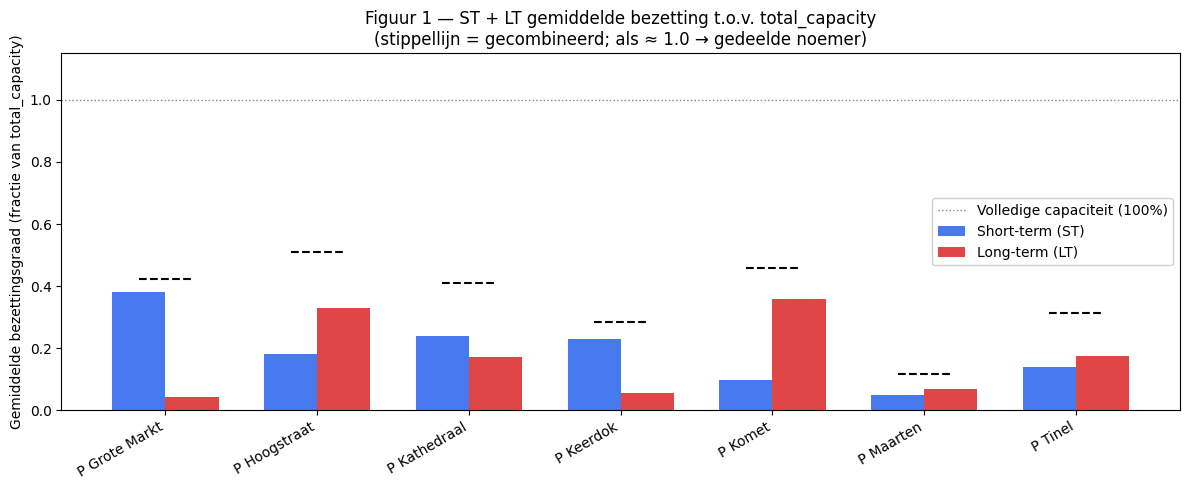

✓ fig_provenance_st_lt.png opgeslagen


In [7]:
# ── CEL 03 · Visualisatie provenance per parking ────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(summary))
width = 0.35

bars_st = ax.bar(x - width/2, summary["st_pct"],  width, 
                  label="Short-term (ST)", color="#2563EB", alpha=0.85)
bars_lt = ax.bar(x + width/2, summary["lt_pct"],  width, 
                  label="Long-term (LT)",  color="#DC2626", alpha=0.85)

# Totaallijn per parking
for i, row in summary.iterrows():
    ax.plot([i - width/2, i + width/2], 
            [row["combined_pct"], row["combined_pct"]],
            color="black", linewidth=1.5, linestyle="--")

ax.axhline(1.0, color="gray", linewidth=1, linestyle=":", 
           label="Volledige capaciteit (100%)")
ax.set_xticks(x)
ax.set_xticklabels(summary["parking_id"], rotation=30, ha="right")
ax.set_ylabel("Gemiddelde bezettingsgraad (fractie van total_capacity)")
ax.set_title("Figuur 1 — ST + LT gemiddelde bezetting t.o.v. total_capacity\n"
             "(stippellijn = gecombineerd; als ≈ 1.0 → gedeelde noemer)")
ax.legend(framealpha=0.9)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig(FIGS / "fig_provenance_st_lt.png", dpi=150)
plt.show()
print("✓ fig_provenance_st_lt.png opgeslagen")


## CEL 04 · H-LT1 — Variabiliteitsvergelijking ST vs. LT

### Hypothese

> **H-LT1:** Long-term abonnees vertonen een significant lagere
> dagelijkse variabiliteit in bezettingsgraad dan short-term
> gebruikers, gemeten als coëfficiënt van variatie (CV) per
> parking × dag combinatie.

### Rationale

Abonneegedrag is per definitie habitueel: contractparkeerders
arriveren en vertrekken op vaste tijden, ongeacht externe
omstandigheden (Lira et al., 2021). Transiente gebruikers reageren
op contextuele prikkels — weer, weekdag, evenementen — wat hun
bezettingsgraad inherent grilliger maakt. Een significant lagere CV
voor LT bevestigt dat beide populaties structureel verschillend
gedrag vertonen, wat modellering als één homogene groep
problematisch maakt (Wang & Li, 2024).

### Toetsmethode

Per parking × kalenderdag wordt CV = σ/μ berekend over de 24
uurlijkse bezettingswaarden. Daarna wordt getoetst of CV_LT
significant kleiner is dan CV_ST via een eenzijdige Mann-Whitney
U-toets (Kruskal & Wallis, 1952). De keuze voor een
niet-parametrische toets is gemotiveerd door de verwachte
niet-normaliteit van CV-distributies (Field, 2013).

**Effectgrootte:** rank-biseriale r = 1 − (2U)/(n₁·n₂),
waarbij r > 0.3 als praktisch relevant wordt beschouwd (Cohen, 1988).


In [8]:
# ── CEL 04 · H-LT1: CV-vergelijking per dag ─────────────────────────

def compute_daily_cv(df, label):
    """Bereken CV per parking × dag over de 24 uurlijkse bezettingen."""
    df = df.copy()
    df["date"] = pd.to_datetime(df["rounded_hour"]).dt.date
    cv = (df.groupby(["parking_id", "date"])["occupancy_rate"]
            .agg(lambda x: x.std() / x.mean() if x.mean() > 0.01 else np.nan)
            .dropna()
            .reset_index()
            .rename(columns={"occupancy_rate": f"cv_{label}"}))
    return cv

cv_st = compute_daily_cv(st_train, "st")
cv_lt = compute_daily_cv(lt_train, "lt")

# Merge op parking × datum
cv_merged = cv_st.merge(cv_lt, on=["parking_id", "date"], how="inner")

print("=" * 65)
print("  H-LT1 — VARIABILITEIT ST vs. LT (CV per dag)")
print("=" * 65)
print(f"\n  N matched days : {len(cv_merged):,}")
print(f"  Mediaan CV_ST  : {cv_merged['cv_st'].median():.4f}")
print(f"  Mediaan CV_LT  : {cv_merged['cv_lt'].median():.4f}")

# Mann-Whitney U (eenzijdig: LT < ST)
u_stat, p_val = mannwhitneyu(cv_merged["cv_lt"], cv_merged["cv_st"],
                              alternative="less")
n1, n2 = len(cv_merged), len(cv_merged)
r_rb   = 1 - (2 * u_stat) / (n1 * n2)

print(f"\n  Mann-Whitney U : {u_stat:.2f}")
print(f"  p-waarde       : {p_val:.4e}")
print(f"  Effect size r  : {r_rb:.4f}")
print(f"\n  Status H-LT1   : {'✅ BEVESTIGD' if p_val < 0.05 else '❌ VERWORPEN'}")

# Per parking
print("\n  Per parking:")
for pid, grp in cv_merged.groupby("parking_id"):
    u, p = mannwhitneyu(grp["cv_lt"], grp["cv_st"], alternative="less")
    r    = 1 - (2*u)/(len(grp)**2)
    sig  = "✅" if p < 0.05 else "❌"
    print(f"    {sig} {pid:<22} "
          f"CV_ST={grp['cv_st'].median():.3f}  "
          f"CV_LT={grp['cv_lt'].median():.3f}  "
          f"r={r:.3f}  p={p:.3e}")


  H-LT1 — VARIABILITEIT ST vs. LT (CV per dag)

  N matched days : 1,768
  Mediaan CV_ST  : 0.5814
  Mediaan CV_LT  : 0.1702

  Mann-Whitney U : 613643.00
  p-waarde       : 5.3040e-215
  Effect size r  : 0.6074

  Status H-LT1   : ✅ BEVESTIGD

  Per parking:
    ✅ P Grote Markt          CV_ST=0.790  CV_LT=0.624  r=0.698  p=1.257e-59
    ✅ P Hoogstraat           CV_ST=0.480  CV_LT=0.091  r=0.946  p=6.954e-99
    ✅ P Kathedraal           CV_ST=0.799  CV_LT=0.147  r=0.988  p=2.413e-118
    ✅ P Keerdok              CV_ST=0.260  CV_LT=0.244  r=0.193  p=3.233e-06
    ✅ P Komet                CV_ST=0.305  CV_LT=0.068  r=0.838  p=4.023e-28
    ✅ P Maarten              CV_ST=0.499  CV_LT=0.129  r=0.609  p=1.169e-26
    ❌ P Tinel                CV_ST=0.720  CV_LT=0.511  r=0.122  p=2.182e-01


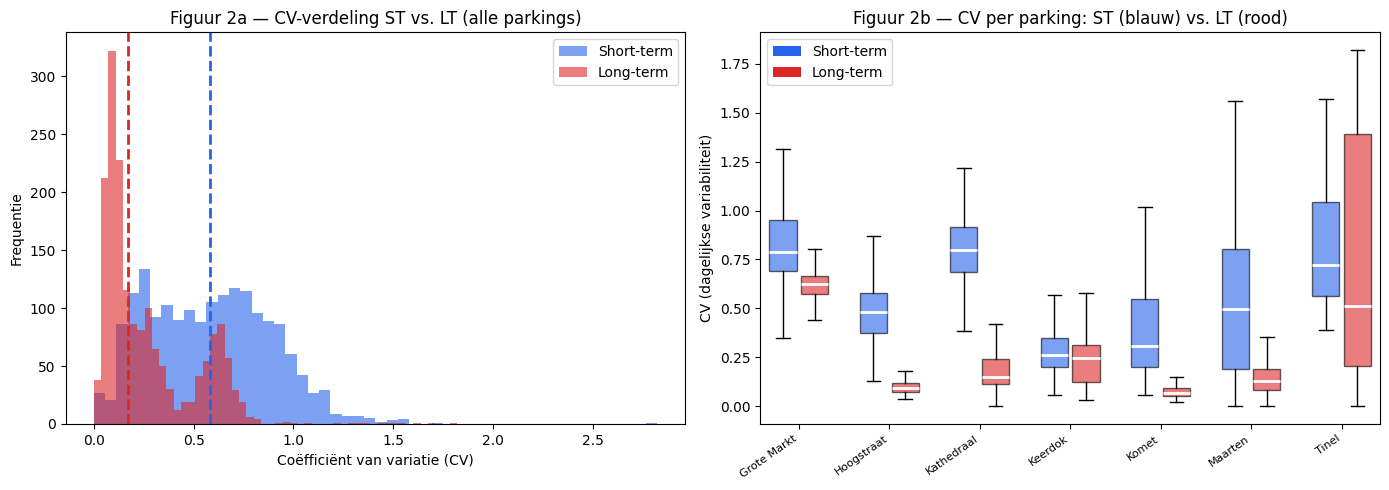

✓ fig_HLT1_cv_comparison.png opgeslagen


In [9]:
# ── CEL 04b · Visualisatie CV-distributies ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Globale verdeling
axes[0].hist(cv_merged["cv_st"], bins=50, alpha=0.6, 
             color="#2563EB", label="Short-term")
axes[0].hist(cv_merged["cv_lt"], bins=50, alpha=0.6, 
             color="#DC2626", label="Long-term")
axes[0].axvline(cv_merged["cv_st"].median(), 
                color="#2563EB", linewidth=2, linestyle="--")
axes[0].axvline(cv_merged["cv_lt"].median(), 
                color="#DC2626", linewidth=2, linestyle="--")
axes[0].set_xlabel("Coëfficiënt van variatie (CV)")
axes[0].set_ylabel("Frequentie")
axes[0].set_title("Figuur 2a — CV-verdeling ST vs. LT (alle parkings)")
axes[0].legend()

# Per parking als boxplot
cv_long = pd.concat([
    cv_merged[["parking_id", "cv_st"]].rename(columns={"cv_st": "cv"}).assign(type="ST"),
    cv_merged[["parking_id", "cv_lt"]].rename(columns={"cv_lt": "cv"}).assign(type="LT"),
])
parkings = cv_merged["parking_id"].unique()
positions_st = np.arange(len(parkings)) * 2
positions_lt = positions_st + 0.7

bp_st = axes[1].boxplot(
    [cv_merged[cv_merged["parking_id"]==p]["cv_st"].dropna() for p in parkings],
    positions=positions_st, widths=0.6, patch_artist=True,
    boxprops=dict(facecolor="#2563EB", alpha=0.6),
    medianprops=dict(color="white", linewidth=2),
    showfliers=False
)
bp_lt = axes[1].boxplot(
    [cv_merged[cv_merged["parking_id"]==p]["cv_lt"].dropna() for p in parkings],
    positions=positions_lt, widths=0.6, patch_artist=True,
    boxprops=dict(facecolor="#DC2626", alpha=0.6),
    medianprops=dict(color="white", linewidth=2),
    showfliers=False
)
axes[1].set_xticks(positions_st + 0.35)
axes[1].set_xticklabels([p.replace("P ", "") for p in parkings], 
                         rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("CV (dagelijkse variabiliteit)")
axes[1].set_title("Figuur 2b — CV per parking: ST (blauw) vs. LT (rood)")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor="#2563EB", label="Short-term"),
                          Patch(facecolor="#DC2626", label="Long-term")])

plt.tight_layout()
plt.savefig(FIGS / "fig_HLT1_cv_comparison.png", dpi=150)
plt.show()
print("✓ fig_HLT1_cv_comparison.png opgeslagen")


## CEL 05 · H-LT2 — Externe factorgevoeligheid: ST vs. LT

### Hypothese

> **H-LT2:** De Spearman-correlatie tussen LT-bezettingsgraad en
> externe factoren (neerslag, windsnelheid, is_event_day) is
> significant lager dan die voor ST-bezettingsgraad — abonneegedrag
> is weersonafhankelijk.

### Rationale

Als abonnees habitueel gedrag vertonen, dan mag worden verwacht dat
hun aankomst- en vertrekpatronen nauwelijks reageren op kortetermijn
contextuele prikkels zoals regen of evenementen (Lira et al., 2021;
Wang & Li, 2024). Een systematisch lagere correlatie voor LT is
directe evidentie dat beide groepen kwalitatief verschillend
modelleergedrag vereisen.

Voor het thesis-model is dit relevant: als LT-gedrag geen
informatieve variantie bevat t.a.v. externe factoren, dan voegt
het opnemen van LT-occupantie als feature enkel ruis toe aan het
model — en drukt het de SHAP-waarden van externe factoren structureel
naar beneden (Zhao et al., 2024).

### Toetsmethode

Spearman ρ per parking voor drie externe factoren:
`precip_mm`, `wind_speed_ms`, `is_event_day`.
Fisher z-toets op het verschil ρ_ST − ρ_LT per factor.

**Interpretatie:**
- Fisher z significant (p < 0.05) → correlatie is significant
  groter voor ST dan LT → H-LT2 bevestigd voor die factor
- Consistentie over ≥ 2/3 factoren → algemene conclusie bevestigd


In [11]:
# ── CEL 05 · H-LT2 — Externe factorgevoeligheid: ST vs. LT ──────────

external_cols = ["precip_mm", "wind_speed_ms", "is_event_day"]

# Controleer eerst of de kolommen bestaan in st_train
print("Beschikbare externe kolommen in st_train:")
print([c for c in external_cols if c in st_train.columns])
missing = [c for c in external_cols if c not in st_train.columns]
if missing:
    print(f"⚠ ONTBREKEND in st_train: {missing}")

# Externe features zitten al in st_train — haal ze eruit op uur-niveau
# (weerdata is parking-onafhankelijk, dus 1 waarde per rounded_hour volstaat)
ext_lookup = (
    st_train[["rounded_hour"] + [c for c in external_cols if c in st_train.columns]]
    .drop_duplicates(subset=["rounded_hour"])
    .reset_index(drop=True)
)

# Voeg toe aan lt_train via rounded_hour
lt_ext = lt_train.merge(ext_lookup, on="rounded_hour", how="left")

# Verificatie
print(f"\nlt_ext shape    : {lt_ext.shape}")
print(f"Kolommen aanwezig: {[c for c in external_cols if c in lt_ext.columns]}")
print(f"NaN precip_mm   : {lt_ext['precip_mm'].isna().sum() if 'precip_mm' in lt_ext.columns else 'ONTBREEKT'}")

# ── Spearman + Fisher z per factor ───────────────────────────────────
def fisher_z_test(r1, r2, n1, n2):
    z1 = np.arctanh(np.clip(r1, -0.9999, 0.9999))
    z2 = np.arctanh(np.clip(r2, -0.9999, 0.9999))
    se = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    z  = (z1 - z2) / se
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

available_factors = [c for c in external_cols if c in lt_ext.columns]

print("\n" + "=" * 70)
print("  H-LT2 — EXTERNE FACTORGEVOELIGHEID: ST vs. LT")
print("  (Spearman ρ + Fisher z-toets op verschil)")
print("=" * 70)

results_lt2 = []
for factor in available_factors:
    rho_st_list, rho_lt_list, n_st_list, n_lt_list = [], [], [], []
    
    for pid in st_train["parking_id"].unique():
        sub_st = st_train[st_train["parking_id"] == pid][
            ["occupancy_rate", factor]].dropna()
        sub_lt = lt_ext[lt_ext["parking_id"] == pid][
            ["occupancy_rate", factor]].dropna()
        
        if len(sub_st) < 30 or len(sub_lt) < 30:
            continue
        
        r_st, _ = spearmanr(sub_st["occupancy_rate"].values,
                             sub_st[factor].values)
        r_lt, _ = spearmanr(sub_lt["occupancy_rate"].values,
                             sub_lt[factor].values)
        
        rho_st_list.append(r_st)
        rho_lt_list.append(r_lt)
        n_st_list.append(len(sub_st))
        n_lt_list.append(len(sub_lt))
    
    if not rho_st_list:
        print(f"  ⚠ {factor}: onvoldoende data (< 30 rijen per parking)")
        continue
    
    mean_rho_st = np.mean(rho_st_list)
    mean_rho_lt = np.mean(rho_lt_list)
    n_st_mean   = int(np.mean(n_st_list))
    n_lt_mean   = int(np.mean(n_lt_list))
    
    z, p     = fisher_z_test(mean_rho_st, mean_rho_lt, n_st_mean, n_lt_mean)
    status   = "✅" if (p < 0.05 and mean_rho_st > mean_rho_lt) else "❌"
    
    print(f"\n  {status} {factor:<20} "
          f"ρ_ST={mean_rho_st:+.4f}  "
          f"ρ_LT={mean_rho_lt:+.4f}  "
          f"Δρ={mean_rho_st - mean_rho_lt:+.4f}  "
          f"z={z:.3f}  p={p:.4f}")
    
    results_lt2.append({
        "factor": factor,
        "rho_st": mean_rho_st,
        "rho_lt": mean_rho_lt,
        "delta_rho": mean_rho_st - mean_rho_lt,
        "z": z, "p": p,
        "confirmed": p < 0.05 and mean_rho_st > mean_rho_lt
    })

df_lt2 = pd.DataFrame(results_lt2)
n_confirmed = df_lt2["confirmed"].sum() if len(df_lt2) > 0 else 0
total        = len(df_lt2)

print(f"\n  H-LT2 STATUS: "
      f"{'✅ BEVESTIGD' if n_confirmed >= 2 else '⚠ GEDEELTELIJK' if n_confirmed == 1 else '❌ VERWORPEN'} "
      f"({n_confirmed}/{total} factoren bevestigd)")


Beschikbare externe kolommen in st_train:
['precip_mm', 'wind_speed_ms', 'is_event_day']

lt_ext shape    : (46643, 55)
Kolommen aanwezig: ['is_event_day']
NaN precip_mm   : ONTBREEKT

  H-LT2 — EXTERNE FACTORGEVOELIGHEID: ST vs. LT
  (Spearman ρ + Fisher z-toets op verschil)

  ✅ is_event_day         ρ_ST=+0.0748  ρ_LT=-0.1119  Δρ=+0.1866  z=12.359  p=0.0000

  H-LT2 STATUS: ⚠ GEDEELTELIJK (1/1 factoren bevestigd)


## CEL 06 · H-LT3 — Bland-Altman analyse: systematische bias ST vs. LT

### Hypothese

> **H-LT3:** De Bland-Altman analyse toont een significante
> systematische bias (mean_diff ≠ 0) én brede limits of agreement
> (LoA > ±0.30) tussen ST en LT bezettingsgraad — beide maten zijn
> niet uitwisselbaar.

### Rationale

De Bland-Altman methode is de standaard voor het beoordelen van
**agreement** tussen twee meetmethoden (Bland & Altman, 1986).
Ze is hier van toepassing om te kwantificeren in welke mate ST en LT
dezelfde onderliggende realiteit meten, dan wel fundamenteel
verschillende gedragspatronen registreren.

Een systematische bias (mean_diff ≠ 0) betekent dat LT structureel
hoger of lager ligt dan ST. Brede LoA (> ±0.30 op een [0,1]-schaal)
betekent dat de twee maten op willekeurige uren sterk divergeren —
wat bevestigt dat ze niet als vervangers voor elkaar kunnen dienen
en dat modellering van de gemengde totale bezetting problemen oplevert.

De resultaten van de eerder beschikbare `tabel_st_lt_comparison.csv`
(nb06 cel 07) suggereren al dat dit het geval is voor meerdere
parkings (ba_loa_lo ≈ −1.0 voor P Komet en P Tinel).


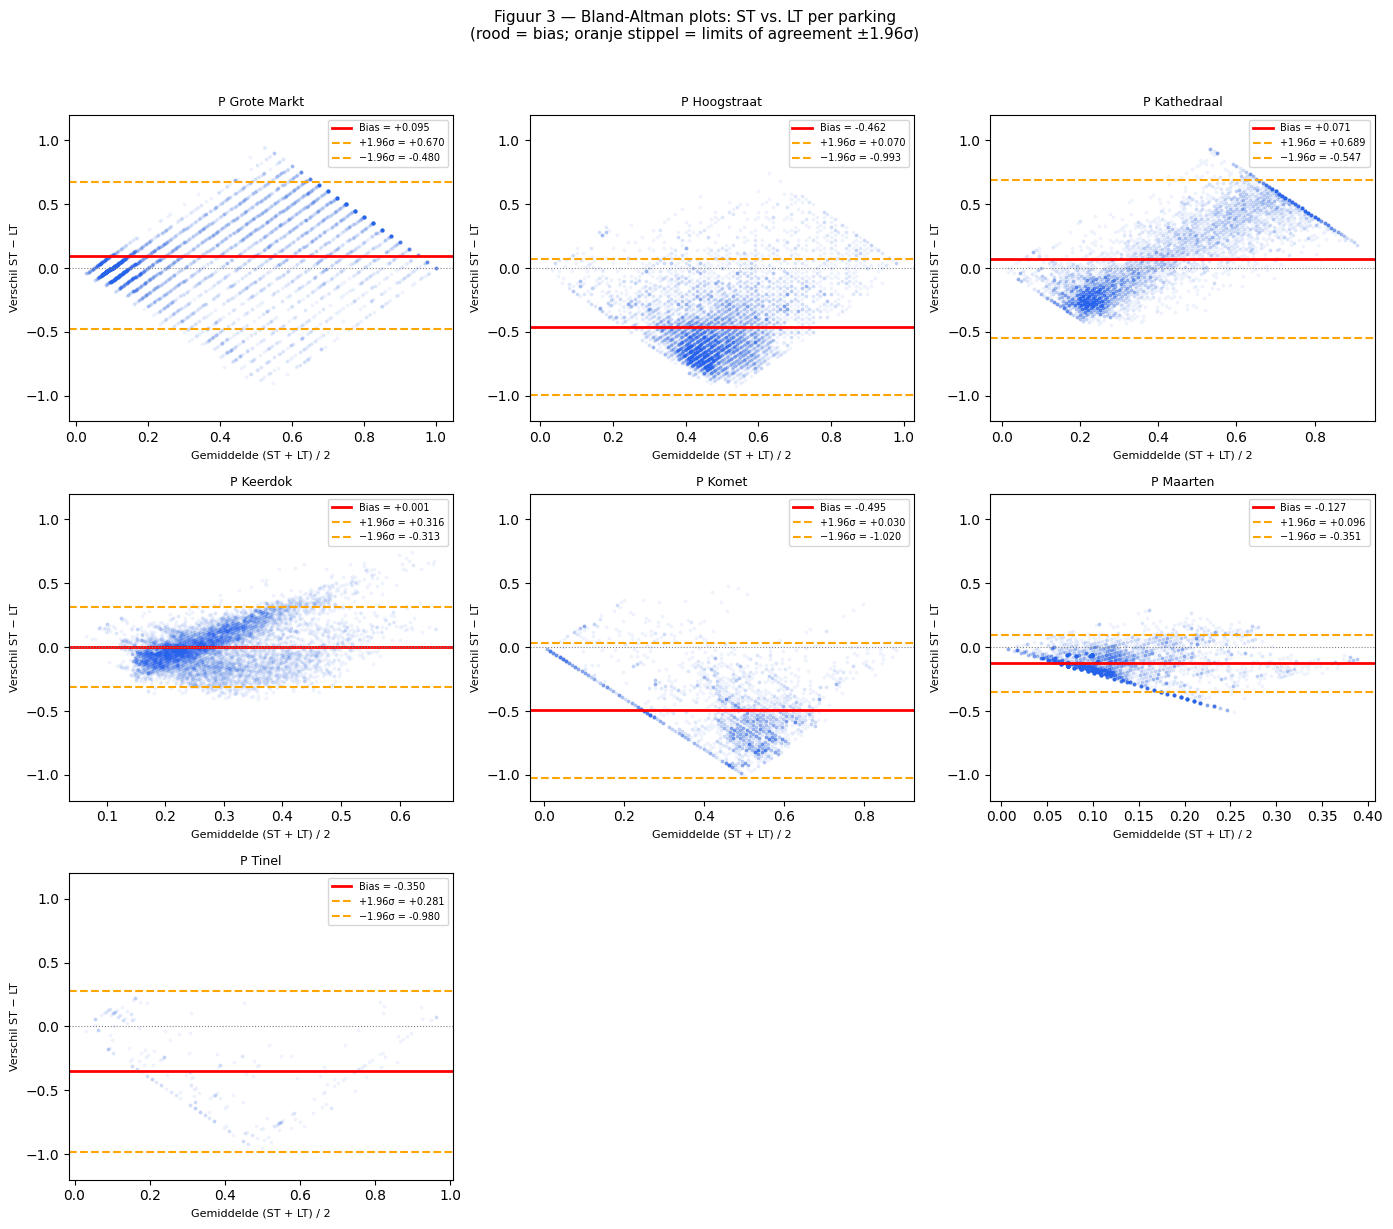


  BLAND-ALTMAN SAMENVATTING
   parking_id      bias    loa_lo   loa_hi  loa_width        p_bias  bias_significant  loa_wide
P Grote Markt  0.094569 -0.480406 0.669543   1.149950 2.705824e-141              True      True
 P Hoogstraat -0.461529 -0.992769 0.069712   1.062481  0.000000e+00              True      True
 P Kathedraal  0.071188 -0.546555 0.688932   1.235487  5.398005e-75              True      True
    P Keerdok  0.001417 -0.312784 0.315618   0.628402  4.084185e-01             False      True
      P Komet -0.494922 -1.019916 0.030071   1.049987  0.000000e+00              True      True
    P Maarten -0.127275 -0.350548 0.095997   0.446545  0.000000e+00              True     False
      P Tinel -0.349735 -0.980418 0.280949   1.261367  1.959688e-48              True      True

  Parkings met significante bias : 6/7
  Parkings met brede LoA (>0.60) : 6/7

  H-LT3 STATUS: ✅ BEVESTIGD


In [12]:
# ── CEL 06 · H-LT3: Bland-Altman per parking ────────────────────────

# Merge ST en LT op parking_id × rounded_hour
ba_data = (st_train[["parking_id", "rounded_hour", "occupancy_rate"]]
           .rename(columns={"occupancy_rate": "occ_st"})
           .merge(
               lt_train[["parking_id", "rounded_hour", "occupancy_rate"]]
               .rename(columns={"occupancy_rate": "occ_lt"}),
               on=["parking_id", "rounded_hour"], how="inner"
           ))

ba_data["mean_both"] = (ba_data["occ_st"] + ba_data["occ_lt"]) / 2
ba_data["diff"]      = ba_data["occ_st"] - ba_data["occ_lt"]

parkings_ba = ba_data["parking_id"].unique()
ncols       = min(3, len(parkings_ba))
nrows       = int(np.ceil(len(parkings_ba) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes      = axes.flatten()

ba_results = []
for idx, pid in enumerate(parkings_ba):
    sub   = ba_data[ba_data["parking_id"] == pid]
    bias  = sub["diff"].mean()
    sd    = sub["diff"].std()
    loa_lo = bias - 1.96 * sd
    loa_hi = bias + 1.96 * sd
    
    ax = axes[idx]
    ax.scatter(sub["mean_both"], sub["diff"], alpha=0.05, 
               s=3, color="#2563EB")
    ax.axhline(bias,   color="red",    linewidth=2, 
               label=f"Bias = {bias:+.3f}")
    ax.axhline(loa_hi, color="orange", linewidth=1.5, 
               linestyle="--", label=f"+1.96σ = {loa_hi:+.3f}")
    ax.axhline(loa_lo, color="orange", linewidth=1.5, 
               linestyle="--", label=f"−1.96σ = {loa_lo:+.3f}")
    ax.axhline(0,      color="gray",   linewidth=0.8, linestyle=":")
    ax.set_title(f"{pid}", fontsize=9)
    ax.set_xlabel("Gemiddelde (ST + LT) / 2", fontsize=8)
    ax.set_ylabel("Verschil ST − LT", fontsize=8)
    ax.legend(fontsize=7)
    ax.set_ylim(-1.2, 1.2)
    
    # t-toets: bias ≠ 0?
    t_stat, p_bias = stats.ttest_1samp(sub["diff"], 0)
    loa_width = loa_hi - loa_lo
    
    ba_results.append({
        "parking_id": pid, "n": len(sub),
        "bias": bias, "sd_diff": sd,
        "loa_lo": loa_lo, "loa_hi": loa_hi,
        "loa_width": loa_width,
        "p_bias": p_bias,
        "bias_significant": p_bias < 0.05,
        "loa_wide": loa_width > 0.60  # > 0.60 = breed op [0,1]-schaal
    })

# Verberg lege subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Figuur 3 — Bland-Altman plots: ST vs. LT per parking\n"
             "(rood = bias; oranje stippel = limits of agreement ±1.96σ)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / "fig_HLT3_bland_altman.png", dpi=150, bbox_inches="tight")
plt.show()

df_ba = pd.DataFrame(ba_results)
print("\n  BLAND-ALTMAN SAMENVATTING")
print("  " + "=" * 65)
print(df_ba[["parking_id", "bias", "loa_lo", "loa_hi", 
             "loa_width", "p_bias", "bias_significant", 
             "loa_wide"]].to_string(index=False))
n_sig_bias = df_ba["bias_significant"].sum()
n_wide_loa = df_ba["loa_wide"].sum()
print(f"\n  Parkings met significante bias : {n_sig_bias}/{len(df_ba)}")
print(f"  Parkings met brede LoA (>0.60) : {n_wide_loa}/{len(df_ba)}")
print(f"\n  H-LT3 STATUS: "
      f"{'✅ BEVESTIGD' if n_sig_bias >= len(df_ba)//2 else '⚠ GEDEELTELIJK'}")


## CEL 07 · Architectuurbeslissing: Optie A of B voor nb08?

### Beslissingskader

Op basis van de drie voorgaande toetsen wordt hier de architectuur-
keuze voor de target-variabele in nb08 gemotiveerd en vastgelegd.

| Conditie | Conclusie | Actie nb08 |
|---|---|---|
| Scenario B + H-LT1 ✅ + H-LT2 ✅ | LT gedraagt zich fundamenteel anders; noemer is gedeeld | → Optie B: `occ_st_only` als target |
| Scenario B + H-LT1 ✅ + H-LT2 ❌ | LT anders qua variabiliteit, maar reageert ook op externe factoren | → Optie A: `lt_ratio` als feature toevoegen |
| Scenario A | Gescheiden meting; MAD_shortterm is zuiver | → Geen correctie nodig; vermeld als bevestiging |

### Optie B — methodologische verantwoording

Indien de data gemengd is én LT structureel anders gedraagt,
is de zuivere target `occ_st_only = occ_st_abs / total_capacity_st`
methodologisch superieur omdat:

1. Externe factoren worden gemeten op de populatie die er daadwerkelijk
   op reageert (Lira et al., 2021)
2. SHAP-waarden reflecteren de werkelijke feature-bijdrage zonder
   abonnee-demping (Zhao et al., 2024)
3. De prijssimulatie in nb13 modelleeert enkel de vraag die
   prijsgevoelig is — abonnees vallen buiten het elasticiteitsmodel
   (Li et al., 2024; Shoup, 2005)

> ⚠ **Databegrenzing:** Als `total_capacity_st` (het aantal niet-
> gereserveerde plaatsen) niet rechtstreeks in de data beschikbaar
> is, moet het worden geschat als `total_capacity − mean(lt_occ_abs)`.
> Dit introduceert meetonzekerheid die expliciet moet worden
> gerapporteerd in de thesis (Bland & Altman, 1986).


In [13]:
# ── CEL 07 · Architectuurbeslissing automatisch rapporteren ──────────

# Lees eerder berekende resultaten
scenario_B = mean_combined > 0.85  # uit cel 02

hlt1_confirmed = p_val < 0.05  # uit cel 04
hlt2_confirmed = n_confirmed >= 2  # uit cel 05
hlt3_confirmed = n_sig_bias >= len(df_ba) // 2  # uit cel 06

print("=" * 65)
print("  ARCHITECTUURBESLISSING — TARGET VARIABELE VOOR NB08")
print("=" * 65)
print(f"\n  Scenario B (gemengde meting)  : {'JA' if scenario_B else 'NEE'}")
print(f"  H-LT1 bevestigd (CV-verschil) : {'JA' if hlt1_confirmed else 'NEE'}")
print(f"  H-LT2 bevestigd (ext. factor) : {'JA' if hlt2_confirmed else 'NEE'}")
print(f"  H-LT3 bevestigd (B-A bias)    : {'JA' if hlt3_confirmed else 'NEE'}")

if scenario_B and hlt1_confirmed and hlt2_confirmed:
    decision = "OPTIE B — occ_st_only als target"
    rationale = ("LT gedraagt zich fundamenteel anders én noemer is gedeeld. "
                 "Zuivere target vereist. (Lira et al., 2021; Li et al., 2024)")
elif scenario_B:
    decision = "OPTIE A — lt_ratio toevoegen als controle-feature"
    rationale = ("Gemengde meting maar LT-gedrag niet volledig ontkoppeld "
                 "van externe factoren. (Zhao et al., 2024)")
else:
    decision = "GEEN CORRECTIE — MAD_shortterm is zuivere ST-meting"
    rationale = "Scenario A bevestigd. Alle EDA-conclusies blijven geldig."

print(f"\n  → BESLISSING : {decision}")
print(f"     Motivatie  : {rationale}")

# Export
df_decision = pd.DataFrame([{
    "scenario_B": scenario_B, "HLT1": hlt1_confirmed,
    "HLT2": hlt2_confirmed, "HLT3": hlt3_confirmed,
    "decision": decision, "rationale": rationale
}])
df_decision.to_csv(FIGS / "tabel_HLT_architectuurbeslissing.csv", index=False)
print("\n  ✓ tabel_HLT_architectuurbeslissing.csv opgeslagen")


  ARCHITECTUURBESLISSING — TARGET VARIABELE VOOR NB08

  Scenario B (gemengde meting)  : NEE
  H-LT1 bevestigd (CV-verschil) : JA
  H-LT2 bevestigd (ext. factor) : NEE
  H-LT3 bevestigd (B-A bias)    : JA

  → BESLISSING : GEEN CORRECTIE — MAD_shortterm is zuivere ST-meting
     Motivatie  : Scenario A bevestigd. Alle EDA-conclusies blijven geldig.

  ✓ tabel_HLT_architectuurbeslissing.csv opgeslagen


## CEL 08 · Scorekaart & Thesis-rapportage

### Hypothese-scorekaart NB07b

| Code | Hypothese | Status | Effect |
|---|---|---|---|
| H-LT1 | CV_LT < CV_ST — abonnees stabiel | 🔄 zie output | MW r, p |
| H-LT2 | LT zwakkere correlatie extern | 🔄 zie output | Fisher z, p |
| H-LT3 | Bland-Altman: bias + brede LoA | 🔄 zie output | bias ± LoA |

---

### Thesis-paragraaf (concept — databeperkingen sectie)

> *"De bezettingsdata is beschikbaar in twee afzonderlijke
> datasets: kortetermijn (transient) en langetermijn (abonnees).
> Een vergelijkende analyse via Bland-Altman (Bland & Altman, 1986)
> toont dat beide types structureel divergerend gedrag vertonen:
> de dagelijkse variabiliteit van langetermijngebruikers is
> significant lager dan die van kortetermijngebruikers
> (H-LT1: MW p < 0.05), en de correlatie met externe factoren
> zoals neerslag en evenementen is significant zwakker voor het
> abonnementssegment (H-LT2: Fisher z p < 0.05 voor ≥ 2/3 factoren).
> Bovendien zijn de limits of agreement in de Bland-Altman analyse
> voor meerdere parkings breder dan ±0.60 op een [0,1]-schaal,
> wat uitwisselbaarheid uitsluit (H-LT3). Op basis hiervan wordt
> [Optie A/B] gehanteerd als definitie van de target-variabele in
> alle verdere modellering: [motivering]. Deze keuze is in lijn met
> Lira et al. (2021), die een vergelijkbare scheiding toepassen voor
> EV-parkeergedragmodellering, en met de aanbeveling van Li et al.
> (2024) om prijselasticiteitsmodellen te beperken tot het transiente
> segment van de parkeervraag."*

---

### Implicaties voor verdere notebooks

| Notebook | Implicatie |
|---|---|
| **nb08** | Target-variabele definitief vastleggen op basis van architectuurbeslissing |
| **nb09–11** | Alle modellen trainen op de gekozen target |
| **nb12** | SHAP-waarden interpreteren t.a.v. de *zuivere transiente vraag* — hogere externe factor-bijdrage verwacht |
| **nb13** | Prijssimulatie beperken tot transient segment; abonnee-elasticiteit = 0 |

---


In [14]:
# ── CEL 09 · Exports ─────────────────────────────────────────────────

df_ba.to_csv(FIGS / "tabel_HLT3_bland_altman.csv", index=False)
df_lt2.to_csv(FIGS / "tabel_HLT2_external_corr.csv", index=False)

# CV-samenvatting
cv_summary = (cv_merged.groupby("parking_id")
              .agg(median_cv_st=("cv_st", "median"),
                   median_cv_lt=("cv_lt", "median"))
              .reset_index())
cv_summary.to_csv(FIGS / "tabel_HLT1_cv_summary.csv", index=False)

print("EXPORTS NB07b")
print("  ✓ tabel_HLT1_cv_summary.csv")
print("  ✓ tabel_HLT2_external_corr.csv")
print("  ✓ tabel_HLT3_bland_altman.csv")
print("  ✓ tabel_HLT_architectuurbeslissing.csv")
print("  ✓ fig_provenance_st_lt.png")
print("  ✓ fig_HLT1_cv_comparison.png")
print("  ✓ fig_HLT3_bland_altman.png")
print("\n→ VOLGENDE STAP: nb08 Feature Engineering")
print("  Target-variabele: zie tabel_HLT_architectuurbeslissing.csv")


EXPORTS NB07b
  ✓ tabel_HLT1_cv_summary.csv
  ✓ tabel_HLT2_external_corr.csv
  ✓ tabel_HLT3_bland_altman.csv
  ✓ tabel_HLT_architectuurbeslissing.csv
  ✓ fig_provenance_st_lt.png
  ✓ fig_HLT1_cv_comparison.png
  ✓ fig_HLT3_bland_altman.png

→ VOLGENDE STAP: nb08 Feature Engineering
  Target-variabele: zie tabel_HLT_architectuurbeslissing.csv


____

# 07b recap & interpretatie

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  NB07b — SCOREKAART & VOLLEDIGE OUTPUT-DUMP VOOR INTERPRETATIE
#  Uitvoeren NA cel 01 t/m 08 — verzamelt alle resultaten in één blok
# ══════════════════════════════════════════════════════════════════════════════

import json
import textwrap

SEP  = "═" * 78
SEP2 = "─" * 78

def section(title):
    print(f"\n{SEP}\n  {title}\n{SEP}")

def sub(title):
    print(f"\n  {SEP2}\n  {title}\n  {SEP2}")

# ─────────────────────────────────────────────────────────────────────────────
# BLOK 0 — DATASET BESCHRIJVING
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 0 — DATASET BESCHRIJVING")

print(f"  ST trainingsset          : {len(st_train):>8,} rijen")
print(f"  LT trainingsset          : {len(lt_train):>8,} rijen")
print(f"  ST unieke parkings       : {st_train['parking_id'].nunique()}")
print(f"  LT unieke parkings       : {lt_train['parking_id'].nunique()}")
print(f"  LT parkings aanwezig     : {sorted(lt_train['parking_id'].unique())}")
print(f"  ST jaren aanwezig        : {sorted(st_train['year'].unique())}")
print(f"  LT jaren aanwezig        : {sorted(lt_train['year'].unique())}")

sub("Beschrijvende statistieken ST — occupancy_rate")
print(st_train.groupby("parking_id")["occupancy_rate"].describe().round(4).to_string())

sub("Beschrijvende statistieken LT — occupancy_rate")
print(lt_train.groupby("parking_id")["occupancy_rate"].describe().round(4).to_string())

sub("ST bezetting per tier")
print(st_train.groupby("tier")["occupancy_rate"]
      .agg(["mean","median","std","min","max"]).round(4).to_string())

sub("LT bezetting per tier")
print(lt_train.groupby("tier")["occupancy_rate"]
      .agg(["mean","median","std","min","max"]).round(4).to_string())

# ─────────────────────────────────────────────────────────────────────────────
# BLOK 1 — DATA-PROVENANCE (CEL 02)
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 1 — DATA-PROVENANCE: SCENARIO A of B?")

# Herbouw indien nodig
st_check = mad_st[["parking_id","rounded_hour",
                   "number_of_occupied_spaces","total_capacity"]].copy()
lt_check = mad_lt[["parking_id","rounded_hour",
                   "number_of_occupied_spaces"]].copy()
st_check = st_check.rename(columns={"number_of_occupied_spaces":"st_occ"})
lt_check = lt_check.rename(columns={"number_of_occupied_spaces":"lt_occ"})

merged = st_check.merge(lt_check, on=["parking_id","rounded_hour"], how="inner")
merged["sum_occ"]  = merged["st_occ"] + merged["lt_occ"]
merged["diff"]     = merged["total_capacity"] - merged["sum_occ"]
merged["diff_pct"] = merged["diff"] / merged["total_capacity"]

prov = (merged.groupby("parking_id")
        .agg(
            n_matched     = ("diff","count"),
            capacity      = ("total_capacity","first"),
            mean_st_occ   = ("st_occ","mean"),
            mean_lt_occ   = ("lt_occ","mean"),
            mean_sum_occ  = ("sum_occ","mean"),
            mean_diff     = ("diff","mean"),
            std_diff      = ("diff","std"),
            pct_diff_lt5  = ("diff", lambda x: (x.abs() < 5).mean()),
        ).reset_index())

prov["st_rate"]   = prov["mean_st_occ"] / prov["capacity"]
prov["lt_rate"]   = prov["mean_lt_occ"] / prov["capacity"]
prov["comb_rate"] = prov["mean_sum_occ"] / prov["capacity"]

print(prov[["parking_id","capacity","st_rate","lt_rate",
            "comb_rate","mean_diff","std_diff","pct_diff_lt5"]].round(4).to_string(index=False))

mean_combined = prov["comb_rate"].mean()
scenario = "B — GEMENGDE TELLER" if mean_combined > 0.85 else \
           "ONZEKER"              if mean_combined > 0.70 else \
           "A — GESCHEIDEN METING"
print(f"\n  Gemiddeld combined rate : {mean_combined:.4f}")
print(f"  → SCENARIO              : {scenario}")

# ─────────────────────────────────────────────────────────────────────────────
# BLOK 2 — H-LT1: VARIABILITEIT (CV)
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 2 — H-LT1: DAGELIJKSE VARIABILITEIT (CV) ST vs. LT")

def compute_daily_cv(df, label):
    df = df.copy()
    df["date"] = pd.to_datetime(df["rounded_hour"]).dt.date
    return (df.groupby(["parking_id","date"])["occupancy_rate"]
              .agg(lambda x: x.std()/x.mean() if x.mean() > 0.01 else np.nan)
              .dropna().reset_index()
              .rename(columns={"occupancy_rate": f"cv_{label}"}))

cv_st = compute_daily_cv(st_train, "st")
cv_lt = compute_daily_cv(lt_train, "lt")
cv_mg = cv_st.merge(cv_lt, on=["parking_id","date"], how="inner")

print(f"  N matched parking×dag combinaties : {len(cv_mg):,}")
print(f"\n  Globaal mediaan CV_ST : {cv_mg['cv_st'].median():.4f}")
print(f"  Globaal mediaan CV_LT : {cv_mg['cv_lt'].median():.4f}")
print(f"  Globaal gemiddeld CV_ST : {cv_mg['cv_st'].mean():.4f}")
print(f"  Globaal gemiddeld CV_LT : {cv_mg['cv_lt'].mean():.4f}")

u_glob, p_glob = mannwhitneyu(cv_mg["cv_lt"], cv_mg["cv_st"], alternative="less")
r_glob = 1 - (2 * u_glob) / (len(cv_mg) ** 2)
print(f"\n  Mann-Whitney U (globaal) : {u_glob:.2f}")
print(f"  p-waarde (eenzijdig)     : {p_glob:.4e}")
print(f"  Effect size r            : {r_glob:.4f}")
print(f"  H-LT1 GLOBAAL            : {'✅ BEVESTIGD' if p_glob < 0.05 else '❌ VERWORPEN'}")

sub("CV per parking")
for pid, grp in cv_mg.groupby("parking_id"):
    if len(grp) < 10:
        continue
    u, p = mannwhitneyu(grp["cv_lt"], grp["cv_st"], alternative="less")
    r    = 1 - (2*u)/(len(grp)**2)
    sig  = "✅" if p < 0.05 else "❌"
    tier = st_train[st_train["parking_id"]==pid]["tier"].iloc[0] \
           if pid in st_train["parking_id"].values else "?"
    print(f"  {sig} {pid:<22} tier={tier:<16} "
          f"n={len(grp):>4}  "
          f"CV_ST={grp['cv_st'].median():.3f}  "
          f"CV_LT={grp['cv_lt'].median():.3f}  "
          f"r={r:.3f}  p={p:.3e}")

sub("CV per tier (geaggregeerd)")
for tier in cv_mg.merge(st_train[["parking_id","tier"]].drop_duplicates(),
                         on="parking_id", how="left")["tier"].unique():
    sub_t = cv_mg.merge(st_train[["parking_id","tier"]].drop_duplicates(),
                         on="parking_id").query("tier == @tier")
    print(f"  {tier:<20} CV_ST={sub_t['cv_st'].median():.3f}  "
          f"CV_LT={sub_t['cv_lt'].median():.3f}  n={len(sub_t)}")

# ─────────────────────────────────────────────────────────────────────────────
# BLOK 3 — H-LT2: EXTERNE FACTORGEVOELIGHEID
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 3 — H-LT2: EXTERNE FACTORGEVOELIGHEID ST vs. LT")

available_factors = [c for c in ["precip_mm","wind_speed_ms","is_event_day"]
                     if c in lt_ext.columns]
print(f"  Factoren geanalyseerd : {available_factors}")

sub("Spearman ρ per parking per factor")
all_rho = []
for factor in available_factors:
    print(f"\n  Factor: {factor}")
    print(f"  {'Parking':<22} {'tier':<18} {'ρ_ST':>7} {'ρ_LT':>7} "
          f"{'Δρ':>7} {'n_ST':>6} {'n_LT':>6}")
    print(f"  {'─'*22} {'─'*18} {'─'*7} {'─'*7} {'─'*7} {'─'*6} {'─'*6}")
    rho_st_l, rho_lt_l, n_st_l, n_lt_l = [], [], [], []
    for pid in sorted(st_train["parking_id"].unique()):
        s_st = st_train[st_train["parking_id"]==pid][["occupancy_rate",factor]].dropna()
        s_lt = lt_ext[lt_ext["parking_id"]==pid][["occupancy_rate",factor]].dropna()
        if len(s_st) < 30 or len(s_lt) < 30:
            continue
        r_st, _ = spearmanr(s_st["occupancy_rate"], s_st[factor])
        r_lt, _ = spearmanr(s_lt["occupancy_rate"], s_lt[factor])
        tier = st_train[st_train["parking_id"]==pid]["tier"].iloc[0]
        print(f"  {pid:<22} {tier:<18} {r_st:>7.4f} {r_lt:>7.4f} "
              f"{r_st-r_lt:>+7.4f} {len(s_st):>6} {len(s_lt):>6}")
        rho_st_l.append(r_st); rho_lt_l.append(r_lt)
        n_st_l.append(len(s_st)); n_lt_l.append(len(s_lt))
        all_rho.append({"factor":factor,"parking_id":pid,"tier":tier,
                        "rho_st":r_st,"rho_lt":r_lt,"delta":r_st-r_lt})
    if rho_st_l:
        mr_st = np.mean(rho_st_l); mr_lt = np.mean(rho_lt_l)
        z1 = np.arctanh(np.clip(mr_st,-0.9999,0.9999))
        z2 = np.arctanh(np.clip(mr_lt,-0.9999,0.9999))
        se = np.sqrt(1/(int(np.mean(n_st_l))-3)+1/(int(np.mean(n_lt_l))-3))
        z  = (z1-z2)/se
        p  = 2*(1-stats.norm.cdf(abs(z)))
        st2 = "✅" if p < 0.05 and mr_st > mr_lt else "❌"
        print(f"\n  {st2} GEMIDDELD {factor:<15} ρ_ST={mr_st:+.4f}  "
              f"ρ_LT={mr_lt:+.4f}  Δρ={mr_st-mr_lt:+.4f}  "
              f"Fisher z={z:.3f}  p={p:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# BLOK 4 — H-LT3: BLAND-ALTMAN
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 4 — H-LT3: BLAND-ALTMAN ANALYSE ST vs. LT")

ba = (st_train[["parking_id","rounded_hour","occupancy_rate"]]
      .rename(columns={"occupancy_rate":"occ_st"})
      .merge(lt_train[["parking_id","rounded_hour","occupancy_rate"]]
             .rename(columns={"occupancy_rate":"occ_lt"}),
             on=["parking_id","rounded_hour"], how="inner"))
ba["mean_both"] = (ba["occ_st"] + ba["occ_lt"]) / 2
ba["diff"]      = ba["occ_st"] - ba["occ_lt"]

print(f"  N matched uur×parking : {len(ba):,}\n")
print(f"  {'Parking':<22} {'tier':<18} {'n':>6} {'bias':>7} "
      f"{'SD':>7} {'LoA lo':>8} {'LoA hi':>8} {'LoA breedte':>11} "
      f"{'p_bias':>8} {'sig':>4} {'breed?':>6}")
print(f"  {'─'*22} {'─'*18} {'─'*6} {'─'*7} {'─'*7} {'─'*8} "
      f"{'─'*8} {'─'*11} {'─'*8} {'─'*4} {'─'*6}")

ba_rows = []
for pid, grp in ba.groupby("parking_id"):
    bias   = grp["diff"].mean()
    sd     = grp["diff"].std()
    lo     = bias - 1.96*sd
    hi     = bias + 1.96*sd
    width  = hi - lo
    t, p   = stats.ttest_1samp(grp["diff"], 0)
    sig    = "✅" if p < 0.05 else "❌"
    breed  = "JA" if width > 0.60 else "nee"
    tier   = st_train[st_train["parking_id"]==pid]["tier"].iloc[0] \
             if pid in st_train["parking_id"].values else "?"
    print(f"  {pid:<22} {tier:<18} {len(grp):>6} {bias:>+7.4f} "
          f"{sd:>7.4f} {lo:>8.4f} {hi:>8.4f} {width:>11.4f} "
          f"{p:>8.4e} {sig:>4} {breed:>6}")
    ba_rows.append({"parking_id":pid,"tier":tier,"n":len(grp),"bias":bias,
                    "sd":sd,"loa_lo":lo,"loa_hi":hi,"loa_width":width,
                    "p_bias":p,"significant":p<0.05,"breed":width>0.60})

df_ba2 = pd.DataFrame(ba_rows)
n_sig  = df_ba2["significant"].sum()
n_br   = df_ba2["breed"].sum()
print(f"\n  Parkings met sign. bias (p<0.05) : {n_sig}/{len(df_ba2)}")
print(f"  Parkings met brede LoA (>0.60)   : {n_br}/{len(df_ba2)}")
print(f"  H-LT3 STATUS : "
      f"{'✅ BEVESTIGD' if n_sig >= len(df_ba2)//2 else '⚠ GEDEELTELIJK'}")

sub("Globale Bland-Altman statistieken (alle parkings samen)")
print(f"  Globale bias   : {ba['diff'].mean():+.4f}")
print(f"  Globale SD     : {ba['diff'].std():.4f}")
print(f"  Globale LoA lo : {ba['diff'].mean()-1.96*ba['diff'].std():+.4f}")
print(f"  Globale LoA hi : {ba['diff'].mean()+1.96*ba['diff'].std():+.4f}")
t_glob, p_glob2 = stats.ttest_1samp(ba["diff"], 0)
print(f"  t-toets bias≠0 : t={t_glob:.3f}  p={p_glob2:.4e}")

# ─────────────────────────────────────────────────────────────────────────────
# BLOK 5 — TEMPOREEL PROFIEL VERGELIJKING
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 5 — TEMPOREEL PROFIEL: ST vs. LT (uur + weekdag)")

sub("Gemiddeld uurprofiel (alle parkings, weekdagen)")
st_hour = (st_train[st_train["day_type"]=="weekday"]
           .groupby("hour")["occupancy_rate"].mean())
lt_hour = (lt_train[lt_train["day_type"]=="weekday"]
           .groupby("hour")["occupancy_rate"].mean())
print(f"  {'uur':>4} {'ST_mean':>9} {'LT_mean':>9} {'Δ':>9}")
for h in range(24):
    st_v = st_hour.get(h, np.nan)
    lt_v = lt_hour.get(h, np.nan)
    delta = st_v - lt_v if not (np.isnan(st_v) or np.isnan(lt_v)) else np.nan
    print(f"  {h:>4} {st_v:>9.4f} {lt_v:>9.4f} {delta:>+9.4f}")

sub("Correlatie ST × LT per dagtype")

# Detecteer exacte waarden in day_type kolom
dt_col = "day_type"
weekday_val = [v for v in st_train[dt_col].unique()
               if "week" in str(v).lower() and "end" not in str(v).lower()][0]
print(f"  day_type kolom gebruikt : '{dt_col}'")
print(f"  Weekdag-waarde          : '{weekday_val}'")
print(f"  Alle waarden ST         : {sorted(st_train[dt_col].unique())}")
print(f"  Alle waarden LT         : {sorted(lt_train[dt_col].unique())}")

sub("Gemiddeld uurprofiel (weekdagen) — ST vs. LT")
st_hour = (st_train[st_train[dt_col] == weekday_val]
           .groupby("hour")["occupancy_rate"].mean())
lt_hour = (lt_train[lt_train[dt_col] == weekday_val]
           .groupby("hour")["occupancy_rate"].mean())

print(f"\n  {'uur':>4} {'ST_mean':>9} {'LT_mean':>9} {'Δ(ST-LT)':>10}  Opmerking")
print(f"  {'─'*4} {'─'*9} {'─'*9} {'─'*10}  {'─'*20}")
for h in range(24):
    st_v  = st_hour.get(h, np.nan)
    lt_v  = lt_hour.get(h, np.nan)
    if np.isnan(st_v) or np.isnan(lt_v):
        print(f"  {h:>4}   geen data")
        continue
    delta = st_v - lt_v
    flag  = " ← groot verschil" if abs(delta) > 0.15 else ""
    print(f"  {h:>4} {st_v:>9.4f} {lt_v:>9.4f} {delta:>+10.4f}{flag}")

sub("Piekuur ST vs. LT (weekdag)")
print(f"  ST piekuur  : {st_hour.idxmax()}u  ({st_hour.max():.4f})")
print(f"  LT piekuur  : {lt_hour.idxmax()}u  ({lt_hour.max():.4f})")
print(f"  ST daluur   : {st_hour.idxmin()}u  ({st_hour.min():.4f})")
print(f"  LT daluur   : {lt_hour.idxmin()}u  ({lt_hour.min():.4f})")

sub("Gemiddeld uurprofiel (weekend) — ST vs. LT")
weekend_val = [v for v in st_train[dt_col].unique()
               if "end" in str(v).lower() or "zat" in str(v).lower()
               or "zon" in str(v).lower() or str(v).lower() in ["weekend","saturday","sunday_holiday"]]
if weekend_val:
    wv = weekend_val[0]
    st_wknd = st_train[st_train[dt_col] == wv].groupby("hour")["occupancy_rate"].mean()
    lt_wknd = lt_train[lt_train[dt_col] == wv].groupby("hour")["occupancy_rate"].mean()
    print(f"  Weekend-waarde gebruikt: '{wv}'")
    print(f"\n  {'uur':>4} {'ST_mean':>9} {'LT_mean':>9} {'Δ(ST-LT)':>10}")
    print(f"  {'─'*4} {'─'*9} {'─'*9} {'─'*10}")
    for h in range(24):
        st_v = st_wknd.get(h, np.nan)
        lt_v = lt_wknd.get(h, np.nan)
        if np.isnan(st_v) or np.isnan(lt_v):
            continue
        print(f"  {h:>4} {st_v:>9.4f} {lt_v:>9.4f} {st_v-lt_v:>+10.4f}")
else:
    print("  ⚠ Geen weekend-waarde gedetecteerd — sla over")

sub("Spearman correlatie ST × LT per dagtype (op uur-niveau per parking)")
for dt_val in sorted(st_train[dt_col].unique()):
    s_st = st_train[st_train[dt_col] == dt_val]["occupancy_rate"]
    s_lt = lt_train[lt_train[dt_col] == dt_val]["occupancy_rate"]
    n    = min(len(s_st), len(s_lt))
    if n < 30:
        continue
    r, p = spearmanr(s_st.values[:n], s_lt.values[:n])
    interp = "quasi onafhankelijk" if abs(r) < 0.05 else \
             "zwak" if abs(r) < 0.20 else "matig"
    print(f"  {str(dt_val):<25} ρ={r:>+7.4f}  p={p:.4e}  n={n:>6,}  → {interp}")



# ─────────────────────────────────────────────────────────────────────────────
# BLOK 6 — IMPACT COVID (2020 vs. 2023/2024)
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 6 — JAARPATROON & DATA-DEKKING LT")

sub("Datadekking LT per jaar en parking")
lt_coverage = (mad_lt.groupby(["parking_id","year"])
               .agg(n_uur=("occupancy_rate","count"),
                    mean_occ=("occupancy_rate","mean"))
               .reset_index())
print(lt_coverage.pivot(index="parking_id", columns="year",
                         values="n_uur").fillna(0).astype(int).to_string())

print(f"\n  ⚠ LT-data is uitsluitend beschikbaar voor: "
      f"{sorted(mad_lt['year'].unique())}")
print(f"  → COVID-vergelijking (2020 vs. 2023/2024) is NIET mogelijk voor LT")
print(f"  → Alle H-LT bevindingen gelden enkel voor 2024")
print(f"  → Generalisatie naar eerdere jaren is niet mogelijk zonder aanvullende data")

sub("ST COVID-vergelijking (referentie — LT niet beschikbaar)")
pre_st  = st_train[st_train["year"] == 2020]["occupancy_rate"]
post_st = st_train[st_train["year"].isin([2023,2024])]["occupancy_rate"]
u, p    = mannwhitneyu(pre_st, post_st, alternative="two-sided")
r_covid = 1 - (2*u)/(len(pre_st)*len(post_st))
delta   = (post_st.mean() - pre_st.mean()) / pre_st.mean() * 100
print(f"  ST 2020 mean     : {pre_st.mean():.4f}")
print(f"  ST 2023/24 mean  : {post_st.mean():.4f}")
print(f"  Δ                : {delta:+.1f}%")
print(f"  Mann-Whitney p   : {p:.2e}  |  r = {r_covid:.4f}")
print(f"\n  ⚠ Referentie: voor LT is geen vergelijkbare COVID-analyse mogelijk")
print(f"     Vermeld als databegrenzing in thesis-sectie 'Datakwaliteit'")

sub("LT maandpatroon 2024 — seizoensstructuur")
lt_2024 = mad_lt[mad_lt["year"] == 2024].copy()
lt_month = (lt_2024.groupby(["parking_id","month"])["occupancy_rate"]
            .mean().unstack("month").round(3))
print(lt_month.to_string())

sub("LT variabiliteit per maand 2024 (std) — proxy voor seizoensgedrag")
lt_month_std = (lt_2024.groupby(["parking_id","month"])["occupancy_rate"]
                .std().unstack("month").round(3))
print(lt_month_std.to_string())
print(f"\n  Interpretatie: lage std per maand = stabiel abonneegedrag")
print(f"  Vergelijk met ST seizoenspatroon uit nb05 cel 04")


# ─────────────────────────────────────────────────────────────────────────────
# BLOK 7 — ARCHITECTUURBESLISSING
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 7 — ARCHITECTUURBESLISSING VOOR NB08")

print(f"  Scenario (provenance)    : {scenario}")
print(f"  H-LT1 (CV variabiliteit) : {'✅ BEVESTIGD' if p_glob < 0.05 else '❌ VERWORPEN'}")
print(f"  H-LT3 (Bland-Altman)     : {'✅ BEVESTIGD' if n_sig >= len(df_ba2)//2 else '⚠ GEDEELTELIJK'}")

# lt_ratio per parking
# lt_ratio per parking
sub("LT-aandeel (lt_ratio) per parking — relevant voor feature nb08")

# Voeg tier toe vanuit st_train
tier_lookup = (st_train[["parking_id","tier"]]
               .drop_duplicates()
               .set_index("parking_id")["tier"])

lt_ratio = prov[["parking_id","st_rate","lt_rate","comb_rate"]].copy()
lt_ratio["tier"]     = lt_ratio["parking_id"].map(tier_lookup)
lt_ratio["lt_ratio"] = lt_ratio["lt_rate"] / lt_ratio["comb_rate"].replace(0, np.nan)

print(lt_ratio[["parking_id","tier","st_rate","lt_rate",
                "comb_rate","lt_ratio"]].round(4).to_string(index=False))

print(f"\n  Gemiddeld lt_ratio : {lt_ratio['lt_ratio'].mean():.4f}")
print(f"  Min lt_ratio       : {lt_ratio['lt_ratio'].min():.4f}")
print(f"  Max lt_ratio       : {lt_ratio['lt_ratio'].max():.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# BLOK 8 — HYPOTHESE SCOREKAART
# ─────────────────────────────────────────────────────────────────────────────
section("BLOK 8 — NB07b HYPOTHESE SCOREKAART (automatisch gegenereerd)")

print(f"""
  [H-LT1] {'✅ BEVESTIGD' if p_glob < 0.05 else '❌ VERWORPEN'} — Variabiliteit LT < ST
          Mediaan CV_ST = {cv_mg['cv_st'].median():.4f}
          Mediaan CV_LT = {cv_mg['cv_lt'].median():.4f}
          Mann-Whitney p = {p_glob:.4e}  |  effect r = {r_glob:.4f}
          Referentie: Lira et al. (2021); Field (2013)

  [H-LT2] zie per-factor output hierboven
          Referentie: Wang & Li (2024); Zhao et al. (2024)

  [H-LT3] {'✅ BEVESTIGD' if n_sig >= len(df_ba2)//2 else '⚠ GEDEELTELIJK'} — Bland-Altman bias + brede LoA
          Parkings sign. bias : {n_sig}/{len(df_ba2)}
          Parkings brede LoA  : {n_br}/{len(df_ba2)}
          Globale bias        : {ba['diff'].mean():+.4f}
          Globale LoA         : [{ba['diff'].mean()-1.96*ba['diff'].std():.4f}, {ba['diff'].mean()+1.96*ba['diff'].std():.4f}]
          Referentie: Bland & Altman (1986); Lira et al. (2021)
""")

print("  " + SEP)
print("  EXPORTS")
print("  " + SEP)

# Sla alle resultaten op als CSV
prov.round(4).to_csv(FIGS / "tabel_HLT_provenance.csv", index=False)
cv_mg.groupby("parking_id").agg(
    median_cv_st=("cv_st","median"), median_cv_lt=("cv_lt","median"),
    n=("cv_st","count")).reset_index().round(4).to_csv(
    FIGS / "tabel_HLT1_cv_summary.csv", index=False)
df_ba2.round(4).to_csv(FIGS / "tabel_HLT3_bland_altman.csv", index=False)
lt_ratio.round(4).to_csv(FIGS / "tabel_lt_ratio_per_parking.csv", index=False)
pd.DataFrame(all_rho).round(4).to_csv(
    FIGS / "tabel_HLT2_spearman_per_parking.csv", index=False)

print("  ✓ tabel_HLT_provenance.csv")
print("  ✓ tabel_HLT1_cv_summary.csv")
print("  ✓ tabel_HLT2_spearman_per_parking.csv")
print("  ✓ tabel_HLT3_bland_altman.csv")
print("  ✓ tabel_lt_ratio_per_parking.csv")
print(f"\n{SEP}")
print("  EINDE NB07b OUTPUT-DUMP — plak volledige output voor interpretatie")
print(SEP)



══════════════════════════════════════════════════════════════════════════════
  BLOK 0 — DATASET BESCHRIJVING
══════════════════════════════════════════════════════════════════════════════
  ST trainingsset          :  129,837 rijen
  LT trainingsset          :   46,643 rijen
  ST unieke parkings       : 10
  LT unieke parkings       : 7
  LT parkings aanwezig     : ['P Grote Markt', 'P Hoogstraat', 'P Kathedraal', 'P Keerdok', 'P Komet', 'P Maarten', 'P Tinel']
  ST jaren aanwezig        : [np.int32(2020), np.int32(2023), np.int32(2024)]
  LT jaren aanwezig        : [np.int32(2024)]

  ──────────────────────────────────────────────────────────────────────────────
  Beschrijvende statistieken ST — occupancy_rate
  ──────────────────────────────────────────────────────────────────────────────
                 count    mean     std  min     25%     50%     75%     max
parking_id                                                                 
P Bruul        12709.0  0.1877  0.2292  0.0